In [102]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [103]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [104]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [105]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [ ]:
def fit_features(train_df: pd.DataFrame) -> dict:
    """Calcule les mappings sur le train set uniquement."""
    df = train_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    # Outliers : corriger AVANT de calculer les stats
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

    mappings = {
        "freq_gare": df["gare"].value_counts(normalize=True),
        "retard_moyen_gare": df.groupby("gare")[cols_retard].mean().mean(axis=1),
    }
    return mappings


def transform_features(df: pd.DataFrame, mappings: dict) -> pd.DataFrame:
    """Applique le feature engineering en utilisant les mappings du train."""
    df = df.copy()

    # Date
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # Encodage cyclique
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # Frequency encoding gare (depuis le train set)
    df["encoded_gare"] = df["gare"].map(mappings["freq_gare"]).fillna(0)

    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    # Features agrégées
    df["somme_retard_prev_trains"] = df["p2q0"] + df["p3q0"] + df["p4q0"]
    df["somme_retard_prev_gares"] = df["p0q2"] + df["p0q3"] + df["p0q4"]

    # Retard moyen par gare (depuis le train set)
    df["retard_moyen_gare"] = df["gare"].map(mappings["retard_moyen_gare"]).fillna(0)

    # Nombre d'arrêts par train/date
    df["nb_arrets"] = df.groupby(["train", "date"])["arret"].transform("count")

    # Drop colonnes inutiles
    cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0", "date", "day_of_week", "month", "gare", "train"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

In [ ]:
# Fit sur train, transform sur train et test
mappings = fit_features(x_train)
x_train_fe = transform_features(x_train, mappings)
x_test_fe = transform_features(x_test, mappings)

In [108]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos,encoded_train,encoded_gare,somme_retard_prev_trains,somme_retard_prev_gares,retard_moyen_gare,retard_moyen_par_train,nb_arrets
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,1.000000,0.000007,0.044566,1.0,-6.0,-0.566903,-0.200000,5
1,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,1.000000,0.000007,0.047422,0.0,2.0,-0.093991,-0.200000,5
2,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,1.000000,0.000007,0.039021,-1.0,-1.0,-0.183342,-0.200000,5
3,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,1.000000,0.000007,0.041726,-2.0,0.0,-0.436343,-0.200000,5
4,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,1.000000,0.000007,0.043806,-3.0,4.0,-0.316142,-0.200000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.951057,0.309017,0.000028,0.011484,-7.0,-3.0,-0.066706,-0.850877,19
667260,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.951057,0.309017,0.000028,0.011627,-1.0,1.0,0.336298,-0.850877,19
667261,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.951057,0.309017,0.000028,0.013987,1.0,-5.0,0.394514,-0.850877,19
667262,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.951057,0.309017,0.000028,0.001278,5.0,1.0,0.395858,-0.850877,19


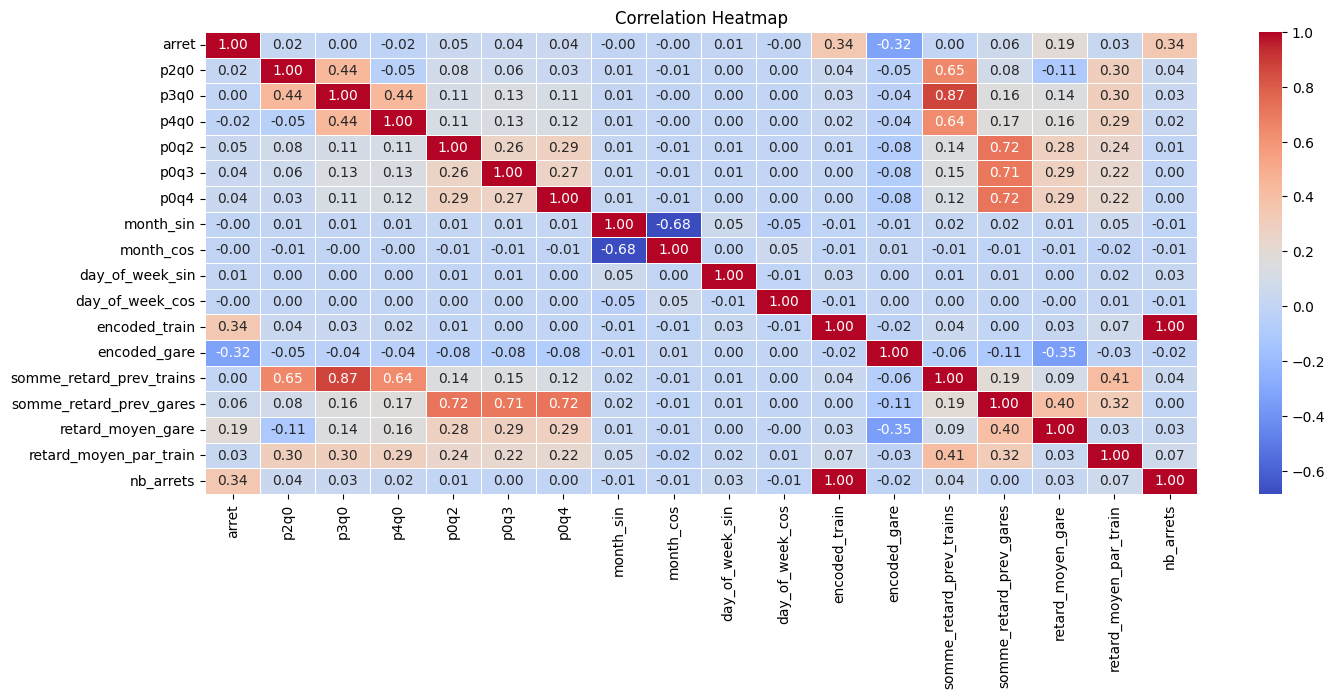

In [109]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [119]:
train_train = x_train["train"].unique()
train_test = x_test["train"].unique()

for train in train_test:
    if train in train_train:
        print(f"Train {train}")

Train ILFNOD
Train NSGFHH


In [120]:
gare_train = x_train["gare"].unique()
gare_test = x_test["gare"].unique()

for gare in gare_test:
    if gare in gare_train:
        print(f"Train {gare}")

Train VXY
Train AZA
Train KYF
Train AVU
Train JEQ
Train JLR
Train MZE
Train PLR
Train ZFB
Train HVA
Train ZAL
Train QYY
Train JBZ
Train EOH
Train KOG
Train FFU
Train UAK
Train PLF
Train JYH
Train OCA
Train ZVY
Train RLW
Train QHI
Train TVD
Train ZHN
Train JUJ
Train VIS
Train DGG
Train KCK
Train OJA
Train TXP
Train OWI
Train ARX
Train OCB
Train XTD
Train ELZ
Train LXX
Train KDN
Train XEH
Train KLN
Train WII
Train RUP
Train LNI
Train GHQ
Train NZC
Train RDN
Train RSZ
Train GDN
Train EME
Train FDV
Train XIL
Train UYT
Train RAN
Train BAP
Train GDU
Train CFK
Train WJF
Train AVF
Train RDU
Train JOD
Train NPF
Train JAQ
Train EAU
Train TRE
Train YWQ
Train MRI
Train XJU
Train WUP
Train YEG
Train IEG
Train GHU
Train NIJ
Train OML
Train AUW
Train QDF
Train WQT
Train DCD
Train WBF
Train ADU
Train UPZ
Train PDG


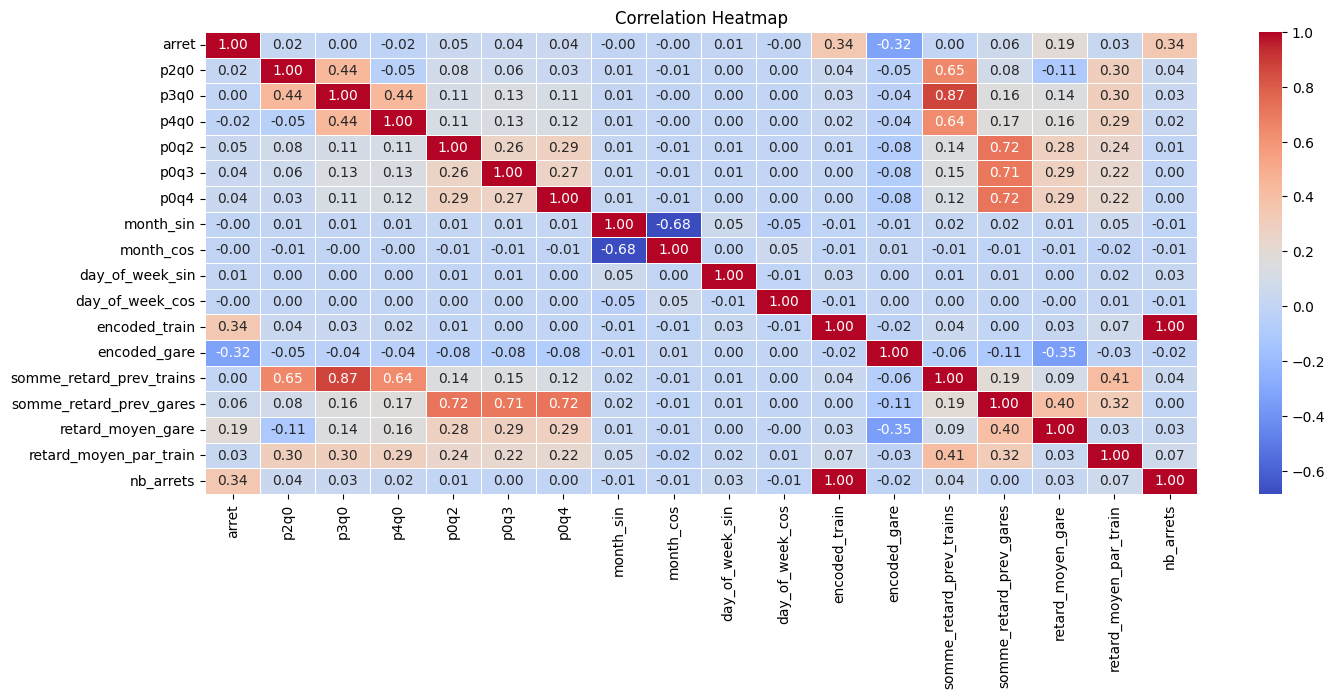

In [111]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"].values

## Modeles

In [ ]:
import xgboost as xgb

SEED = 42

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(x_train_fe))
test_preds = np.zeros(len(x_test_fe))
fold_scores = []

X = x_train_fe.values
X_test = x_test_fe.values

# Paramètres XGBoost
xgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": SEED
}

print(f"Entraînement en {kf.n_splits} folds...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / kf.n_splits

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
oof_score = mean_absolute_error(y, oof_preds)
print(f"  OOF global        | MAE = {oof_score:.4f}")
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")